In [38]:
import pandas as pd

df = pd.read_csv("astram_event_data.csv.csv")

print(df.shape)
df.head()

(8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [39]:
print(df.columns.tolist())

['id', 'event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude', 'address', 'end_address', 'event_cause', 'requires_road_closure', 'start_datetime', 'end_datetime', 'status', 'authenticated', 'modified_datetime', 'map_file', 'direction', 'description', 'veh_type', 'veh_no', 'corridor', 'priority', 'cargo_material', 'reason_breakdown', 'age_of_truck', 'created_date', 'route_path', 'client_id', 'created_by_id', 'last_modified_by_id', 'assigned_to_police_id', 'citizen_accident_id', 'comment', 'police_station', 'meta_data', 'kgid', 'resolved_at_address', 'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id', 'closed_datetime', 'resolved_by_id', 'resolved_datetime', 'gba_identifier', 'zone', 'junction']


In [40]:
df.isnull().sum().sort_values(ascending=False)

,0
comment,8173
map_file,8173
meta_data,8173
direction,8130
resolved_at_address,8099
resolved_at_latitude,8099
resolved_by_id,8099
resolved_datetime,8099
resolved_at_longitude,8099
assigned_to_police_id,8045


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   object 
 1   event_type             8173 non-null   object 
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   object 
 7   end_address            687 non-null    object 
 8   event_cause            8173 non-null   object 
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   object 
 11  end_datetime           490 non-null    object 
 12  status                 8173 non-null   object 
 13  authenticated          8173 non-null   object 
 14  modified_datetime      8173 non-null   object 
 15  map_

In [42]:
df['event_type'].value_counts()

,count
event_type,
unplanned,7706
planned,467


In [43]:
df['event_cause'].value_counts()

,count
event_cause,
vehicle_breakdown,4896
others,638
pot_holes,537
construction,480
water_logging,458
accident,365
tree_fall,284
road_conditions,170
congestion,136


In [44]:
df['event_cause'].value_counts().head(30)

,count
event_cause,
vehicle_breakdown,4896
others,638
pot_holes,537
construction,480
water_logging,458
accident,365
tree_fall,284
road_conditions,170
congestion,136


In [45]:
df.groupby('event_cause')['requires_road_closure'].mean().sort_values(ascending=False)

,requires_road_closure
event_cause,
debris,1.000000
vip_movement,0.800000
public_event,0.464286
protest,0.400000
tree_fall,0.394366
construction,0.264583
procession,0.263889
road_conditions,0.123529
others,0.086207


In [46]:
df['start_datetime'] = pd.to_datetime(
    df['start_datetime'],
    format='mixed',
    errors='coerce'
)

df['hour'] = df['start_datetime'].dt.hour

df.groupby('hour').size().sort_values(ascending=False)

,0
hour,
21,817
20,685
6,662
5,661
22,589
19,584
4,560
23,504
7,482


In [47]:
df['start_datetime'].isnull().sum()

np.int64(0)

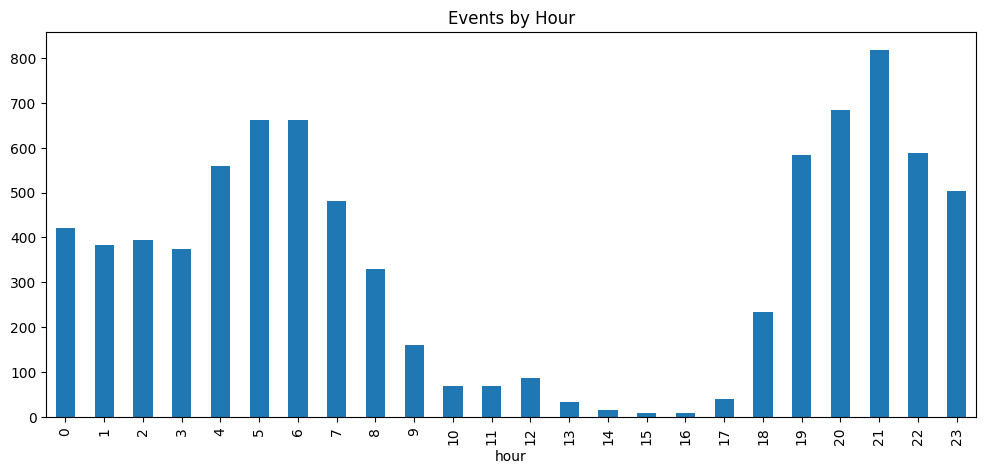

In [48]:
import matplotlib.pyplot as plt

hour_counts = df.groupby('hour').size()

hour_counts.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Events by Hour")
plt.show()

In [49]:
df['day_of_week'] = df['start_datetime'].dt.day_name()

df['day_of_week'].value_counts()

,count
day_of_week,
Thursday,1359
Friday,1258
Tuesday,1252
Saturday,1243
Wednesday,1174
Sunday,967
Monday,920


In [50]:
df.groupby('event_type')['event_cause'].value_counts().head(20)

event_type  event_cause      
planned     construction          311
            public_event           84
            procession             38
            vip_movement           20
            protest                 8
            vehicle_breakdown       3
            tree_fall               2
            others                  1
unplanned   vehicle_breakdown    4893
            others                637
            pot_holes             537
            water_logging         458
            accident              365
            tree_fall             282
            road_conditions       170
            construction          169
            congestion            136
            procession             34
            Debris                 12
            protest                 7
Name: count, dtype: int64

In [51]:
df.groupby('event_cause')['hour'].agg(
    ['mean','min','max','count']
).sort_values('count', ascending=False)

,mean,min,max,count
event_cause,,,,
vehicle_breakdown,11.232230,0,23,4896
others,11.711599,0,23,638
pot_holes,13.325885,0,23,537
construction,14.158333,0,23,480
water_logging,9.067686,0,23,458
accident,12.495890,0,23,365
tree_fall,10.693662,0,23,284
road_conditions,12.835294,0,23,170
congestion,9.242647,0,23,136


In [52]:
df.groupby('event_cause')['day_of_week'].value_counts().head(50)

event_cause           day_of_week
Debris                Friday           4
                      Tuesday          3
                      Wednesday        2
                      Monday           1
                      Saturday         1
                      Thursday         1
Fog / Low Visibility  Tuesday          1
                      Wednesday        1
accident              Tuesday        113
                      Saturday        50
                      Friday          49
                      Thursday        49
                      Wednesday       41
                      Sunday          35
                      Monday          28
congestion            Thursday        33
                      Wednesday       22
                      Sunday          19
                      Friday          17
                      Monday          17
                      Tuesday         16
                      Saturday        12
construction          Tuesday         79
                      Thursday        78
                      Friday          76
                      Saturday        76
                      Wednesday       73
                      Monday          54
                      Sunday          44
debris                Thursday         1
others                Thursday       107
                      Wednesday      102
                      Saturday        97
                      Friday          91
                      Tuesday         84
                      Monday          79
                      Sunday          78
pot_holes             Saturday       151
                      Friday         110
                      Monday          67
                      Thursday        67
                      Wednesday       53
                      Tuesday         50
                      Sunday          39
procession            Monday          23
                      Sunday          18
                      Tuesday         12
                      Wednesday        7
                      Friday           4
                      Saturday         4
Name: count, dtype: int64

In [53]:
df.groupby('event_cause')[
    'requires_road_closure'
].mean().sort_values(
    ascending=False
)

,requires_road_closure
event_cause,
debris,1.000000
vip_movement,0.800000
public_event,0.464286
protest,0.400000
tree_fall,0.394366
construction,0.264583
procession,0.263889
road_conditions,0.123529
others,0.086207


In [54]:
severity_map = {
    'vip_movement':5,
    'protest':5,
    'public_event':4,
    'procession':4,
    'construction':3,
    'accident':4,
    'tree_fall':4,
    'water_logging':3,
    'vehicle_breakdown':2,
    'congestion':3,
    'road_conditions':2,
    'pot_holes':1,
    'others':2
}

df['severity_score'] = (
    df['event_cause']
    .map(severity_map)
    .fillna(1)
)

In [55]:
closure_prob = {
    'vip_movement':80,
    'public_event':46,
    'protest':40,
    'tree_fall':39,
    'construction':26,
    'procession':26,
    'road_conditions':12,
    'water_logging':8,
    'vehicle_breakdown':4,
    'accident':3,
    'pot_holes':2
}

df['closure_score'] = (
    df['event_cause']
    .map(closure_prob)
    .fillna(0)
)

In [56]:
peak_hours = [5,6,19,20,21,22]

df['peak_hour'] = (
    df['hour']
    .isin(peak_hours)
    .astype(int)
)

In [57]:
high_risk_days = [
    'Thursday',
    'Friday',
    'Tuesday',
    'Saturday'
]

df['high_risk_day'] = (
    df['day_of_week']
    .isin(high_risk_days)
    .astype(int)
)

In [58]:
df[
[
'severity_score',
'closure_score',
'peak_hour',
'high_risk_day'
]
].head()

,severity_score,closure_score,peak_hour,high_risk_day
0,2.0,4.0,0,1
1,2.0,4.0,0,1
2,2.0,0.0,1,1
3,4.0,39.0,0,1
4,2.0,4.0,0,1


In [59]:
df[
[
'severity_score',
'closure_score',
'peak_hour',
'high_risk_day'
]
].describe()

,severity_score,closure_score,peak_hour,high_risk_day
count,8173.000000,8173.000000,8173.000000,8173.000000
mean,2.273339,7.212651,0.489172,0.625474
std,0.746452,10.182154,0.499913,0.484030
min,1.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,0.000000,0.000000
50%,2.000000,4.000000,0.000000,1.000000
75%,2.000000,4.000000,1.000000,1.000000
max,5.000000,80.000000,1.000000,1.000000


In [60]:
df['risk_score'] = (
      df['severity_score'] * 10
    + df['closure_score'] * 0.5
    + df['peak_hour'] * 15
    + df['high_risk_day'] * 10
)

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['risk_score'] = scaler.fit_transform(
    df[['risk_score']]
) * 100

In [62]:
df['risk_score'].describe()

,risk_score
count,8173.000000
mean,28.506697
std,13.810185
min,0.000000
25%,20.952381
50%,25.714286
75%,35.238095
max,100.000000


In [63]:
df[['event_cause','risk_score']] \
.groupby('event_cause') \
.mean() \
.sort_values('risk_score',ascending=False)

,risk_score
event_cause,
vip_movement,90.238095
protest,71.428571
tree_fall,61.445339
public_event,60.850340
procession,49.484127
construction,45.386905
accident,40.919765
water_logging,38.109794
congestion,30.917367


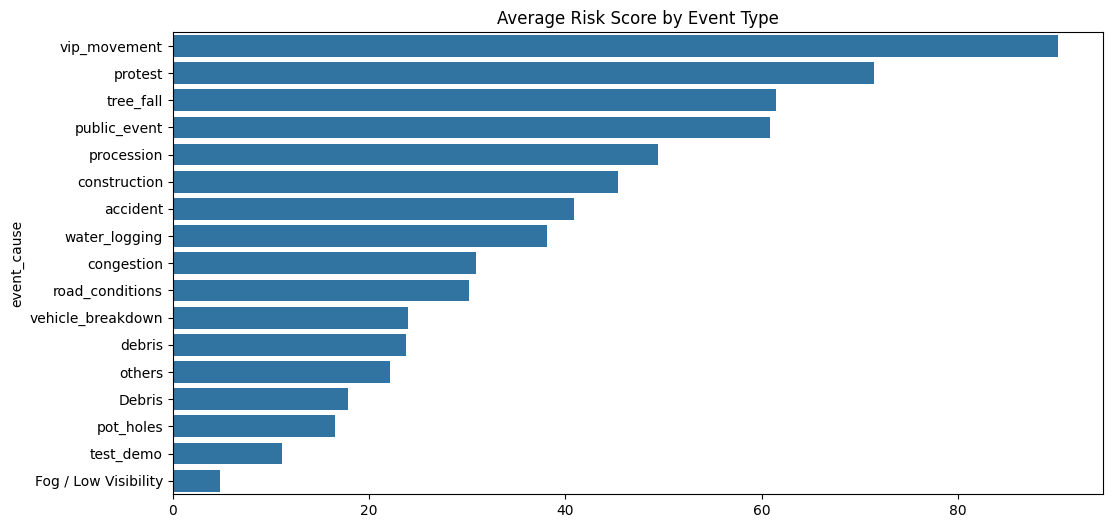

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

risk_by_event = (
    df.groupby('event_cause')['risk_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=risk_by_event.values,
    y=risk_by_event.index
)

plt.title("Average Risk Score by Event Type")
plt.show()

In [65]:
df['recommended_police'] = (
    df['severity_score'] * 2
    + df['closure_score'] * 0.3
).round().astype(int)

df['recommended_police'] = (
    df['recommended_police']
    .clip(lower=2)
)

In [66]:
df['recommended_barricades'] = (
    df['closure_score'] / 5
).round().astype(int)

In [67]:
df['diversion_required'] = (
    df['risk_score'] >= 60
).astype(int)

In [68]:
df[
[
'event_cause',
'risk_score',
'recommended_police',
'recommended_barricades',
'diversion_required'
]
].head(20)

,event_cause,risk_score,recommended_police,recommended_barricades,diversion_required
0,vehicle_breakdown,20.952381,5,1,0
1,vehicle_breakdown,20.952381,5,1,0
2,others,33.333333,4,0,0
3,tree_fall,56.666667,20,8,0
4,vehicle_breakdown,20.952381,5,1,0
5,accident,39.523810,9,1,0
6,vehicle_breakdown,20.952381,5,1,0
7,others,33.333333,4,0,0
8,public_event,50.476190,22,9,0
9,vehicle_breakdown,35.238095,5,1,0


In [69]:
df.groupby('event_cause')[
[
'recommended_police',
'recommended_barricades',
'diversion_required'
]
].mean().sort_values(
'recommended_police',
ascending=False
)

,recommended_police,recommended_barricades,diversion_required
event_cause,,,
vip_movement,34.0,16.0,1.000000
public_event,22.0,9.0,0.666667
protest,22.0,8.0,0.866667
tree_fall,20.0,8.0,0.503521
procession,16.0,5.0,0.138889
construction,14.0,5.0,0.000000
accident,9.0,1.0,0.000000
road_conditions,8.0,2.0,0.000000
water_logging,8.0,2.0,0.000000


In [70]:
df['impact_score'] = (
      df['risk_score'] * 0.5
    + df['recommended_police'] * 1.5
    + df['recommended_barricades'] * 2
)

In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['impact_score'] = scaler.fit_transform(
    df[['impact_score']]
) * 100

In [72]:
df['impact_level'] = pd.cut(
    df['impact_score'],
    bins=[0,25,50,75,100],
    labels=[
        'Low',
        'Medium',
        'High',
        'Critical'
    ]
)

In [73]:
df[
[
'event_cause',
'impact_score',
'impact_level'
]
].head()

,event_cause,impact_score,impact_level
0,vehicle_breakdown,13.058608,Low
1,vehicle_breakdown,13.058608,Low
2,others,15.128205,Low
3,tree_fall,54.871795,High
4,vehicle_breakdown,13.058608,Low


In [74]:
df.groupby('event_cause')[
'impact_score'
].mean().sort_values(
ascending=False
)

,impact_score
event_cause,
vip_movement,96.245421
protest,62.857143
public_event,60.327054
tree_fall,56.709746
procession,42.878510
construction,38.994963
accident,25.353756
water_logging,24.657613
road_conditions,21.592329


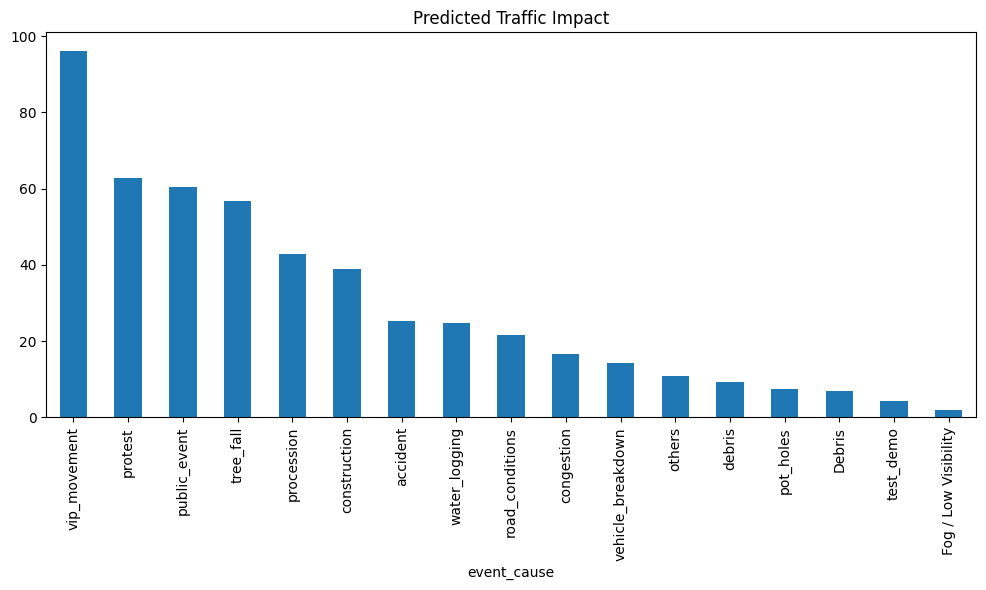

In [75]:
impact_summary = (
    df.groupby('event_cause')['impact_score']
    .mean()
    .sort_values(ascending=False)
)

impact_summary.plot(
    kind='bar',
    figsize=(12,5)
)
plt.title("Predicted Traffic Impact")
plt.show()

In [76]:
import numpy as np

df['resource_efficiency'] = (
    df['recommended_police'] /
    (df['impact_score'] + 1)
)

df['resource_efficiency'] = (
    df['resource_efficiency']
    .replace([np.inf,-np.inf],0)
)

In [77]:
df['deployment_quality'] = np.where(
    df['resource_efficiency'] > 0.5,
    'Over Deployment',
    'Optimal'
)

In [78]:
df['deployment_quality'].value_counts()

,count
deployment_quality,
Optimal,7984
Over Deployment,189


In [79]:
df.groupby('event_cause')[
'resource_efficiency'
].mean().sort_values(
ascending=False
)

,resource_efficiency
event_cause,
Fog / Low Visibility,1.214454
test_demo,0.875269
pot_holes,0.432270
Debris,0.404334
others,0.370082
procession,0.366607
road_conditions,0.361532
public_event,0.359843
congestion,0.356142


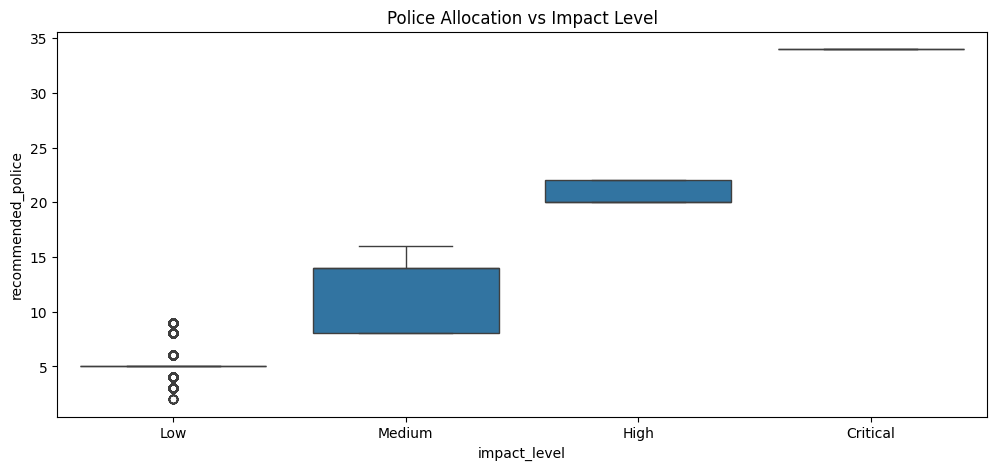

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.boxplot(
    x='impact_level',
    y='recommended_police',
    data=df
)

plt.title(
    "Police Allocation vs Impact Level"
)

plt.show()

In [81]:
df['impact_level'] = pd.cut(
    df['impact_score'],
    bins=[0,20,40,60,100],
    labels=['Low','Medium','High','Critical']
)

In [82]:
df['impact_level'].value_counts()

,count
impact_level,
Low,6296
Medium,1253
High,443
Critical,176


In [83]:
df.groupby('impact_level')[
    ['recommended_police',
     'recommended_barricades']
].mean().round(2)

/tmp/ipykernel_1151/2417304961.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('impact_level')[


,recommended_police,recommended_barricades
impact_level,,
Low,4.79,0.81
Medium,9.88,2.45
High,17.47,6.64
Critical,21.95,9.01


In [84]:
df.groupby('impact_level')[
    'diversion_required'
].mean()

/tmp/ipykernel_1151/1060482118.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('impact_level')[


,diversion_required
impact_level,
Low,0.00000
Medium,0.00000
High,0.14447
Critical,1.00000


In [85]:
df.groupby('impact_level')[
    'impact_score'
].agg(['min','max','mean'])

/tmp/ipykernel_1151/3031178618.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('impact_level')[


,min,max,mean
impact_level,,,
Low,1.520147,19.523810,13.361763
Medium,21.098901,39.597070,28.182194
High,42.783883,60.000000,49.320980
Critical,60.366300,96.336996,64.909674


In [87]:
road_suggestions = {

'vip_movement':[
'Outer Ring Road',
'Hebbal Flyover',
'Airport Service Road'
],

'public_event':[
'MG Road',
'Cubbon Road',
'Residency Road'
],

'protest':[
'Outer Ring Road',
'Bellary Road',
'Hebbal Service Road'
],

'construction':[
'ORR Service Road',
'NICE Road'
],

'tree_fall':[
'Nearest Parallel Street'
],

'accident':[
'Flyover Alternate Route'
],

'water_logging':[
'Elevated Corridor'
]

}

In [88]:
def suggest_route(event):

    if event in road_suggestions:
        return road_suggestions[event]

    return ['No diversion needed']

In [89]:
df['alternate_routes'] = df[
'event_cause'
].apply(suggest_route)

In [90]:
df[
[
'event_cause',
'alternate_routes'
]
].sample(10)

,event_cause,alternate_routes
2617,vehicle_breakdown,[No diversion needed]
1907,vehicle_breakdown,[No diversion needed]
5699,accident,[Flyover Alternate Route]
428,water_logging,[Elevated Corridor]
3943,water_logging,[Elevated Corridor]
5884,vehicle_breakdown,[No diversion needed]
6008,vehicle_breakdown,[No diversion needed]
2916,water_logging,[Elevated Corridor]
5125,construction,"[ORR Service Road, NICE Road]"
2926,vehicle_breakdown,[No diversion needed]


In [91]:
def congestion_reduction(row):

    reduction = 0


    reduction += row['recommended_police'] * 0.6


    reduction += row['recommended_barricades'] * 1.2


    if row['diversion_required']==1:
        reduction += 12


    return min(reduction,50)

In [92]:
df['reduction_score'] = df.apply(
    congestion_reduction,
    axis=1
)

In [96]:
df['post_impact_score'] = (

df['impact_score']

-

df['reduction_score']

).clip(lower=0)

In [98]:
df['reduction_percent'] = (

100

*

df['reduction_score']

/

df['impact_score']

).round(2)

In [99]:
df[
[
'event_cause',

'impact_score',

'reduction_score',

'post_impact_score',

'reduction_percent'

]
].sample(15)

,event_cause,impact_score,reduction_score,post_impact_score,reduction_percent
2721,water_logging,27.948718,7.2,20.748718,25.76
3379,vehicle_breakdown,13.058608,4.2,8.858608,32.16
2267,vehicle_breakdown,13.058608,4.2,8.858608,32.16
6660,vehicle_breakdown,18.553114,4.2,14.353114,22.64
1548,vehicle_breakdown,18.553114,4.2,14.353114,22.64
4027,vehicle_breakdown,9.395604,4.2,5.195604,44.70
6192,vehicle_breakdown,18.553114,4.2,14.353114,22.64
7407,vehicle_breakdown,9.395604,4.2,5.195604,44.70
8107,vehicle_breakdown,13.058608,4.2,8.858608,32.16
3009,water_logging,22.454212,7.2,15.254212,32.07


In [100]:
df[
    df['event_cause'].isin(['vip_movement','protest','public_event','tree_fall'])
][
[
'event_cause',
'impact_score',
'reduction_score',
'post_impact_score',
'reduction_percent'
]
].head(20)

,event_cause,impact_score,reduction_score,post_impact_score,reduction_percent
3,tree_fall,54.871795,21.6,33.271795,39.36
8,public_event,56.336996,24.0,32.336996,42.60
18,tree_fall,60.366300,33.6,26.766300,55.66
21,tree_fall,60.366300,33.6,26.766300,55.66
25,tree_fall,60.366300,33.6,26.766300,55.66
33,tree_fall,60.366300,33.6,26.766300,55.66
48,tree_fall,60.366300,33.6,26.766300,55.66
58,tree_fall,60.366300,33.6,26.766300,55.66
59,tree_fall,60.366300,33.6,26.766300,55.66
60,tree_fall,60.366300,33.6,26.766300,55.66


In [101]:
def predict_event_plan(event_cause, hour, day_of_week):
    event_cause = event_cause.strip()

    severity = severity_map.get(event_cause, 1)
    closure = closure_prob.get(event_cause, 0)

    peak = 1 if hour in [5, 6, 19, 20, 21, 22] else 0
    risky_day = 1 if day_of_week in ['Thursday', 'Friday', 'Tuesday', 'Saturday'] else 0

    raw_risk = (
        severity * 10
        + closure * 0.5
        + peak * 15
        + risky_day * 10
    )

    # approximate normalization based on existing risk_score range
    risk_score = min(100, max(0, raw_risk))

    police = int(round(severity * 2 + closure * 0.3))
    police = max(police, 2)

    barricades = int(round(closure / 5))

    diversion = 1 if risk_score >= 60 else 0

    impact_score = (
        risk_score * 0.5
        + police * 1.5
        + barricades * 2
    )

    impact_score = min(100, impact_score)

    if impact_score < 20:
        impact_level = "Low"
    elif impact_score < 40:
        impact_level = "Medium"
    elif impact_score < 60:
        impact_level = "High"
    else:
        impact_level = "Critical"

    routes = suggest_route(event_cause)

    reduction = (
        police * 0.6
        + barricades * 1.2
        + (12 if diversion == 1 else 0)
    )
    reduction = min(reduction, 50)

    post_impact = max(0, impact_score - reduction)

    reduction_percent = round((reduction / impact_score) * 100, 2) if impact_score > 0 else 0

    return {
        "event_cause": event_cause,
        "hour": hour,
        "day": day_of_week,
        "risk_score": round(risk_score, 2),
        "impact_score": round(impact_score, 2),
        "impact_level": impact_level,
        "recommended_police": police,
        "recommended_barricades": barricades,
        "diversion_required": "Yes" if diversion else "No",
        "alternate_routes": routes,
        "post_impact_score": round(post_impact, 2),
        "estimated_mitigation_percent": reduction_percent
    }

In [102]:
predict_event_plan(
    event_cause="vip_movement",
    hour=21,
    day_of_week="Friday"
)

{'event_cause': 'vip_movement',
 'hour': 21,
 'day': 'Friday',
 'risk_score': 100,
 'impact_score': 100,
 'impact_level': 'Critical',
 'recommended_police': 34,
 'recommended_barricades': 16,
 'diversion_required': 'Yes',
 'alternate_routes': ['Outer Ring Road',
  'Hebbal Flyover',
  'Airport Service Road'],
 'post_impact_score': 50,
 'estimated_mitigation_percent': 50.0}

In [103]:
predict_event_plan(
    event_cause="vehicle_breakdown",
    hour=11,
    day_of_week="Monday"
)

{'event_cause': 'vehicle_breakdown',
 'hour': 11,
 'day': 'Monday',
 'risk_score': 22.0,
 'impact_score': 20.5,
 'impact_level': 'Medium',
 'recommended_police': 5,
 'recommended_barricades': 1,
 'diversion_required': 'No',
 'alternate_routes': ['No diversion needed'],
 'post_impact_score': 16.3,
 'estimated_mitigation_percent': 20.49}